In [1]:
import os
import numpy as np
import joblib
import pandas as pd
import glob
import matplotlib.pyplot as plt
import subprocess

# Paths

In [3]:
main_path = "plink/ref_pca"
eigenallele = f"{main_path}.eigenvec.allele"
plink_exe = "plink/plink1.9.exe"
plink2_exe = "plink/plink2.exe"

# Extract the overlap list from the reference PCA

In [ ]:
print("Extracting Reference SNPs -->")
ref = pd.read_csv(eigenallele, delim_whitespace=True)
ref.iloc[:, 1].to_csv("Reference_SNPs.txt", header=False, index=False)
print(f"Saved {len(ref)} reference SNPs to extract.\n")

# Output

In [ ]:
output_dir = "dtc_pcs"
os.makedirs(output_dir, exist_ok=True)
dtc_files = glob.glob("23andMe/genome_*.txt")

In [9]:
# Need to cleean the file names

References for this section:<br>
https://github.com/psbaltar/rawDNA2vcf/blob/master/23andme_to_vcf.py<br>



In [29]:
for f in dtc_files:
    base_name = os.path.splitext(os.path.basename(f))[0]
    raw_prefix = f"dtc_raw_{base_name}"
    clean_prefix = f"dtc_clean_{base_name}"
    
    # Convert 23andMe files to the same PLINK format as the 1240k dataset
    cmd_convert = [
        plink_exe,
        "--23file", f,
        "--make-bed",
        "--out", raw_prefix
    ]
    try:
        print(f"Processing: {base_name} -->")
        subprocess.run(cmd_convert, check=True, stdout=subprocess.DEVNULL)
    except subprocess.CalledProcessError as e:
        print(f"Error converting {f}: {e}")
        continue

    # Get rid of duplicate enteries
    bim_file = f"{raw_prefix}.bim"
    bim = pd.read_csv(bim_file, sep="\t", header=None, names=["chr", "snp", "cm", "pos", "a1", "a2"])
    
    # Get variants where Allele 1 = Allele 2
    bad_alleles = bim[bim["a1"] == bim["a2"]]["snp"]
    
    # Get duplicate rsIDs
    duplicate_ids = bim[bim.duplicated(subset=["snp"], keep="first")]["snp"]
    
    # Combine and save to list
    bad_snps = pd.concat([bad_alleles, duplicate_ids]).drop_duplicates()
    exclude_file = f"exclude_{base_name}.txt"
    bad_snps.to_csv(exclude_file, index=False, header=False)
    print(f"Found {len(bad_snps)} problematic SNPs (duplicates/identical alleles).")

    # Filter for thr bad SNPs and get the overlap from the 23andMe files
    cmd_filter = [
        plink_exe,
        "--bfile", raw_prefix,
        "--extract", "Reference_SNPs.txt",
        "--exclude", exclude_file,
        "--make-bed",
        "--out", clean_prefix
    ]
    try:
        subprocess.run(cmd_filter, check=True, stdout=subprocess.DEVNULL)
        print("Filtered overlap and removed bad SNPs.")
    except subprocess.CalledProcessError as e:
        print(f"Error filtering {raw_prefix}: {e}")
        continue

    # Fit PCA
    n_pc = 15
    start = 7 # Column of PC1
    end = start + n_pc - 1 # Column of final PC
    pca_output = os.path.join(output_dir, f"{base_name}_pcs")
    
    cmd_pca = [
        plink2_exe,
        "--bfile", clean_prefix,
        "--score", eigenallele, "2", "6","header", "no-mean-imputation",
        "--score-col-nums", f"{start}-{end}",
        "--memory", "2000",
        "--threads", "2",
        "--out", pca_output
    ]
    try:
        subprocess.run(cmd_pca, check=True, stdout=subprocess.DEVNULL)
        print(f"Completed!! Saved to: {pca_output}.sscore\n")
    except subprocess.CalledProcessError as e:
        print(f"Error for {clean_prefix} due to: {e}")

Extracting Reference SNPs...


C:\Users\sindi\AppData\Local\Temp\ipykernel_18848\1677410661.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ref = pd.read_csv(eigenallele, delim_whitespace=True)
C:\Users\sindi\AppData\Local\Temp\ipykernel_18848\1677410661.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ref = pd.read_csv(eigenallele, delim_whitespace=True)


Saved 540216 reference SNPs to extract.

--- Processing: genome_Frances_Stewart_v4_Full_20200420173116 ---
Found 6809 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Success! PCA projected to dtc_pcs\genome_Frances_Stewart_v4_Full_20200420173116_pcs.sscore

--- Processing: genome_hu24385B_v3_Full_20181019043936 ---
Found 20168 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Success! PCA projected to dtc_pcs\genome_hu24385B_v3_Full_20181019043936_pcs.sscore

--- Processing: genome_Joshua_Yoakem_v5_Full_20250129211749 ---
Found 10813 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Success! PCA projected to dtc_pcs\genome_Joshua_Yoakem_v5_Full_20250129211749_pcs.sscore

--- Processing: genome_Simon_Funk_Full_20140330133719 ---
Found 699 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Success! PCA projected to dtc_pcs\genome_Simon_F

# Get the PCA

In [47]:
all_dfs = []

for f in pca_path:
    filename = os.path.basename(f)
    
    parts = filename.split("_")
    name_extracted = f"{parts[1]}_{parts[2]}"
    
    temp_df = pd.read_csv(f, sep=r'\s+')
    temp_df.insert(0, "Name", name_extracted)
    
    all_dfs.append(temp_df)

pca = pd.concat(all_dfs, ignore_index=True)

In [48]:
pca.head()

,Name,#FID,IID,ALLELE_CT,NAMED_ALLELE_DOSAGE_SUM,SCORE1_AVG,SCORE2_AVG,SCORE3_AVG,SCORE4_AVG,SCORE5_AVG,SCORE6_AVG,SCORE7_AVG,SCORE8_AVG,SCORE9_AVG,SCORE10_AVG,SCORE11_AVG,SCORE12_AVG,SCORE13_AVG,SCORE14_AVG,SCORE15_AVG
0,Frances_Stewart,FAM001,ID001,362216,362216,-0.093882,-0.011520,0.001586,0.000584,0.005003,-0.001688,0.025361,0.003413,0.013339,-0.002127,0.036144,-0.005870,0.022239,-0.000937,-0.001059
1,hu24385B_v3,FAM001,ID001,486224,486224,-0.153728,-0.012889,-0.002862,0.009528,0.002623,0.000878,0.015615,0.004601,0.019691,-0.004083,0.042873,-0.009605,0.019788,0.007293,0.005307
2,Joshua_Yoakem,FAM001,ID001,124318,124318,-0.108068,-0.054859,0.021207,-0.007304,0.017395,-0.013117,0.034030,0.008748,0.005090,0.001999,0.040925,0.002892,0.021355,-0.006597,-0.002465
3,Simon_Funk,FAM001,ID001,437962,437962,-0.111256,-0.009377,0.002278,0.007041,0.002201,-0.000955,0.020553,0.003330,0.014342,-0.003139,0.038160,-0.010136,0.020382,0.004334,0.001362


# Exploratory Evaluation

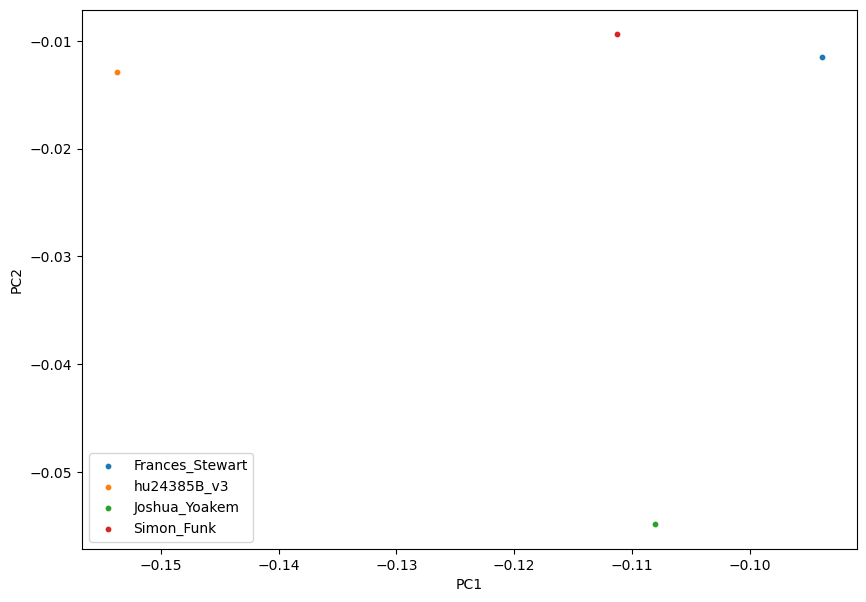

In [50]:
plt.figure(figsize=(10,7))
for pop in pca["Name"].unique():
    sub = pca[pca["Name"]==pop]
    plt.scatter(sub["SCORE1_AVG"],sub["SCORE2_AVG"], label=pop, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()